# Example as from the CFM training script.

## Preparing notebook.

### Libraries.

In [10]:
import os
import sys
import yaml

from hydra import initialize, compose
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
import torch

from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.constants import DataFields, PredictionFields
from sc_exp_design.data.container import DataMixin
from sc_exp_design.models import FlowMatching
from sc_exp_design.training.callbacks import WandBLogger, MetricsCallBack, TrainingCallBacks

sys.path.insert(0, "../../../scripts")

from data_utils import annotate_perturbations, apply_shared_transformations
from ood_utils import split_adata
from train_utils import (
    parse_mlp_config_dictionary,
    parse_nested_mlp_config_dictionary,
    resolve_omegaconf_to_dictionary
)
from validation_utils import validate_on_ood_data

### Constants.

In [11]:
IS_RUN_LOCALLY = False

time_samplers = {}
noise_distributions = {}
activation_functions = {}
optimizers = {}
schedulers = {}
state_transforms = {}
column2tranform = {}


### Reading configurations.

In [12]:
# Initialize Hydra with your config directory
with initialize(
    config_path="../config"
):
    # Compose the config (like what @hydra.main does)
    config = compose(
    config_name="train_cfm",
    overrides=[
        "training=debug",
        "paths=hpc_subset",
        "data=protocol_concat",
        "vf=default_protocol_concat",
    ])

/tmp/ipykernel_3445384/2354406485.py:2: UserWarning: 
The version_base parameter is not specified.
Please specify a compatibility version level, or None.
Will assume defaults for version 1.1
  with initialize(


## Data.

### Reading data.

In [4]:
adata = sc.read_h5ad(config.paths.h5ad_path)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

### Annotating perturbations.

In [13]:
adata = annotate_perturbations(
    adata,
    config.annotation.protocol_columns,
    protocol_obs_key_added=config.annotation.protocol_obs_key_added,
    protocol_sep=config.annotation.protocol_sep,
    one_hot_uns_key_added=config.annotation.one_hot_uns_key_added,
    column2tranform=column2tranform,
    protocol_obsm_key=config.annotation.protocol_obsm_key,
)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one

### Splitting adata.

In [14]:
train_adata, ood_adatas_dict = split_adata(
    adata,
    config.ood.obs_column,
    config.ood.unique_value_ids,
)
train_adata, ood_adatas_dict.keys()

(AnnData object with n_obs × n_vars = 99517 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type', 'protocol_id'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_

### Applying shared transformations.

In [15]:
train_adata, ood_adatas_dict = apply_shared_transformations(
    train_adata,
    ood_adatas_dict,
    config.transforms.scatter_columns,
    scatter_obsm_key=config.transforms.scatter_obsm_key,
    channel_concat_obsm_key=config.transforms.channel_concat_obsm_key,
    pca_obsm_key=config.transforms.pca_obsm_key,
    pca_concat_obsm_key=config.transforms.pca_concat_obsm_key,
    standardize_repr=config.transforms.standardize_repr,
    sample_rep=config.transforms.sample_rep,
    sample_rep_obsm_key=config.transforms.sample_rep_obsm_key,
    repr_params_uns_key=config.transforms.repr_params_uns_key,
    compute_channel_pcs=config.transforms.compute_channel_pcs,
    standardize_channel_feats=config.transforms.standardize_channel_feats,
    channel_feats_obsm_key=config.transforms.channel_feats_obsm_key,
    channel_params_uns_key=config.transforms.channel_params_uns_key,
    standardize_scatter_feats=config.transforms.standardize_scatter_feats,
    scatter_params_uns_key=config.transforms.scatter_params_uns_key,
)
train_adata, ood_adatas_dict

(AnnData object with n_obs × n_vars = 99517 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type', 'protocol_id'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_

## Model.

### Initializing CFM model.

In [16]:
flow_matching =  FlowMatching(
    flow_type=config.flow_matching.flow_type,
    flow_kwargs=resolve_omegaconf_to_dictionary(config.flow_matching.flow_kwargs),
    coupling_type=config.flow_matching.coupling_type,
    coupling_kwargs=resolve_omegaconf_to_dictionary(config.flow_matching.coupling_kwargs),
    time_sampler=time_samplers.get(config.flow_matching.time_sampler, torch.rand),
    device_id=config.flow_matching.device_id,
    generate_from_noise=config.flow_matching.generate_from_noise,
    noise_distribution=noise_distributions.get(config.flow_matching.noise_distribution, torch.randn),
)

### Setting up data.

In [17]:
flow_matching.prepare_train_data(
    train_adata,
    sample_rep=config.data.sample_rep,
    control_key=config.data.control_key,
    perturbations=config.data.perturbations,
    perturbations_in_obsm=config.data.perturbations_in_obsm,
    perturbation_covariates=config.data.perturbation_covariates,
    perturbation_reps=config.data.perturbation_reps,
    load_target_covariates=config.data.load_target_covariates,
    target_covariates=config.data.target_covariates,
    target_covariates_in_obsm=config.data.target_covariates_in_obsm,
    target_covariates_kwargs=resolve_omegaconf_to_dictionary(config.data.target_covariates_kwargs),
)
ood_data_dict = {
    k: flow_matching.data_manager.get_data(v) for k, v in ood_adatas_dict.items()
}

### Visualize train data.

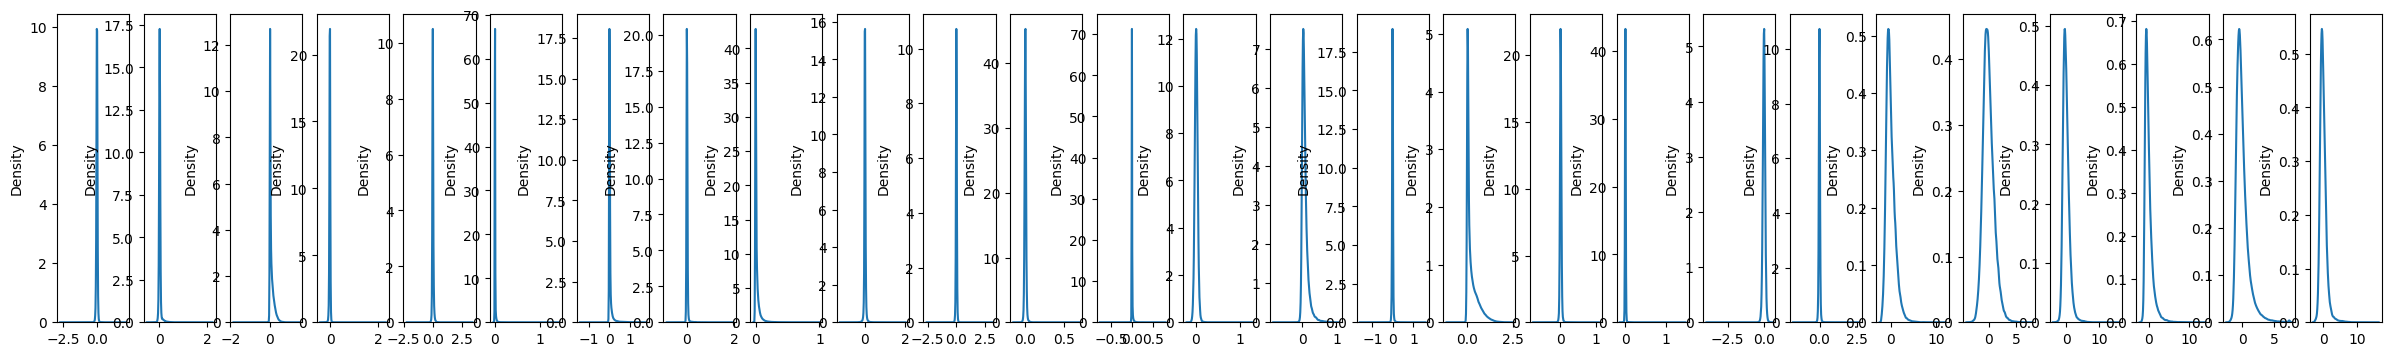

In [18]:
fig, ax = plt.subplots(1, flow_matching.train_data.state_data.shape[-1], figsize=(30, 4))
for idx in range(flow_matching.train_data.state_data.shape[-1]):
    sns.kdeplot(flow_matching.train_data.state_data[:, idx], ax=ax[idx])

### Initializing velocity field.

In [19]:
cvf_config = NeuralVelocityFieldConfig(
    flow_matching.train_data.state_data.shape[-1],
    encode_state=config.vf.encode_state,
    state_encoder_output_dim=config.vf.state_encoder_output_dim,
    state_encoder_mlp_kwargs=parse_mlp_config_dictionary(activation_functions, config.vf.state_encoder_mlp_kwargs),
    encode_time=config.vf.encode_time,
    use_sinusoidal_time_features=config.vf.use_sinusoidal_time_features,
    time_features_num_freqs=config.vf.time_features_num_freqs,
    time_features_max_periods=config.vf.time_features_max_periods,
    time_encoder_output_dim=config.vf.time_encoder_output_dim,
    time_encoder_mlp_kwargs=parse_mlp_config_dictionary(activation_functions, config.vf.time_encoder_mlp_kwargs),
    use_guidance=config.vf.use_guidance,
    encode_conditions=config.vf.encode_conditions,
    perturbation_encoder_output_dim=config.vf.perturbation_encoder_output_dim,
    perturbation_layers_before_pooling=parse_nested_mlp_config_dictionary(activation_functions, config.vf.perturbation_layers_before_pooling),
    perturbation_covariates_not_pooled=config.vf.perturbation_covariates_not_pooled,
    perturbation_pooling=config.vf.perturbation_pooling,
    perturbation_pooling_kwargs=config.vf.perturbation_pooling_kwargs,
    perturbation_layers_after_pooling=parse_mlp_config_dictionary(activation_functions, config.vf.perturbation_layers_after_pooling),
    decoder_mlp_kwargs=parse_mlp_config_dictionary(activation_functions, config.vf.decoder_mlp_kwargs),
    use_source_as_condition=config.vf.use_source_as_condition,
    encode_source=config.vf.encode_source, 
    source_encoder_output_dim=config.vf.source_encoder_output_dim,
    source_encoder_mlp_kwargs=parse_mlp_config_dictionary(activation_functions, config.vf.source_encoder_mlp_kwargs),
    conditioning_type=config.vf.conditioning_type,
    n_resnet_blocks=config.vf.n_resnet_blocks,
    resnet_dropout_prob=config.vf.resnet_dropout_prob,
    resnet_normalization=config.vf.resnet_normalization,
    use_classifier_free_guidance=config.vf.use_classifier_free_guidance,
    cfg_null_condition_token=config.vf.cfg_null_condition_token,
)

### Initializing Neural Velocity Field.

In [20]:
flow_matching.prepare_model(
    cvf_config,
    optimizer_class=optimizers.get(config.model.optimizer_id, torch.optim.Adam),
    optimizer_kwargs=resolve_omegaconf_to_dictionary(config.model.optimizer_kwargs),
    lr_scheduler_class=schedulers.get(config.model.scheduler_id, None),
    lr_scheduler_kwargs=resolve_omegaconf_to_dictionary(config.model.lr_scheduler_kwargs),
    lr_scheduler_step=config.model.lr_scheduler_step,
    num_time_steps=config.model.num_time_steps,
    solver_kwargs=resolve_omegaconf_to_dictionary(config.model.solver_kwargs),
)
print(flow_matching.velocity_field)

NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=27, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=16, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=8, bias=True)
          (1): Identity()
        )
      )
    )
    (condition_encoder): ConditionEncoder(
      (modules_dict): ModuleDict(
        (feats_condition_concat_condition_concat): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=15, out_features=16, bias=True)
              (1): ReLU()
    

### Prepare training callbacks.

In [21]:
wandb_callback = WandBLogger(
    project_name=config.callbacks.wandb_project_name,
    log_dir=config.paths.log_dir,
    config=config,
    **resolve_omegaconf_to_dictionary(config.callbacks.wandb_kwargs),
)
metrics_callback = MetricsCallBack(
    config.callbacks.metrics,
    state_transforms=state_transforms.get(config.training.state_transforms, None),
)
callbacks = TrainingCallBacks(
    [
        wandb_callback,
        metrics_callback
    ]
)

### Train CFM.

In [22]:
flow_matching.train(
    num_training_steps=config.training.num_training_steps,
    valid_freq=config.training.valid_freq,
    train_batch_size=config.training.train_batch_size,
    validation_batch_size=config.training.validation_batch_size,
    state_transforms=state_transforms.get(config.training.state_transforms, None),
    callbacks=callbacks,
    grad_steps_log_interval=config.training.grad_steps_log_interval,
    num_treatments_to_load=config.training.num_treatments_to_load,
    num_samples_per_validation_step=config.training.num_samples_per_validation_step,
    cfg_prob_unconditional=config.training.cfg_prob_unconditional,
    validation_cfg_guidance_strength=config.training.validation_cfg_guidance_strength,
    num_grad_accumulation_steps=config.training.num_grad_accumulation_steps,
    close_wandb_connection=False,
)

  0%|          | 0/100 [00:00<?, ?it/s]wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: fmgs666 (inverse-perturbation-models) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loss: 1.7208: 100%|██████████| 100/100 [00:12<00:00,  7.98it/s]


### Validation.

In [25]:

def predict_on_ood_data(
    N,
    flow_matching,
    ood_data,
):
    control_data = ood_data.control_data
    perturbation_data = ood_data.perturbation_data

    if perturbation_data is not None:
        unique_perts = DataMixin(perturbation_data.apply(lambda x: np.unique(x, axis=0)))
        perts_data = unique_perts.apply(lambda x: torch.from_numpy(x).float().to(flow_matching.device))
        if not flow_matching.generate_from_noise:
            perts_data = perts_data.apply(lambda x: x.unsqueeze(0).repeat(N, 1, 1))
    
    if control_data is not None:
        if not flow_matching.generate_from_noise:
            control_data = control_data.apply(lambda x: x.unsqueeze(0).repeat(N, 1, 1))

    return flow_matching.predict(
        {
            DataFields.SOURCE_STATE: control_data,
            DataFields.PERTURBATION_DATA: perts_data,
        },
        num_samples=N,
    ).detach().cpu().numpy()


def validate_on_ood_data(
    N,
    flow_matching,
    ood_data,
    metrics_callback,
    sep="+"
):
    x1_hat = predict_on_ood_data(
        N, flow_matching, ood_data
    )
    print(x1_hat.shape)
    if ood_data.seen_combinations is not None:
        preds_dict = DataMixin({
            comb_id if isinstance(comb_id, str) else sep.join([str(v) for v in comb_id]): x1_hat[:, idx, :] for idx, comb_id in enumerate(ood_data.seen_combinations)
        })
        preds_dict[DataFields.CONDITION_VALUES] = np.concat(list(preds_dict.values()))
    else:
        ...

    state_data = ood_data.state_data
    treatment_idxs_per_condition = ood_data.treatment_idxs_per_condition
    treatment_idxs_per_condition = DataMixin({
        k if isinstance(k, str) else sep.join([str(v) for v in k]): v for k, v in  treatment_idxs_per_condition.items()
    })
    target_data = treatment_idxs_per_condition.apply(lambda idx: state_data[idx])

    metrics_input = {
        k: {
            PredictionFields.PREDICTION_DATA: preds_dict[k],
            DataFields.TARGET_STATE: target_data[k]
        } for k in target_data.keys()
    }

    return metrics_callback.run_on_valid_step(
        metrics_input
    )

In [26]:
N = 1000
num_time_steps = 100
sep = "+"
splits_metrics_dict = {}
for split_id, split_data in ood_data_dict.items():
    splits_metrics_dict[split_id] = validate_on_ood_data(
        N,
        flow_matching,
        split_data,
        callbacks,
        sep=sep
    )
callbacks.run_on_train_end()

(1000, 1, 27)


UnboundLocalError: cannot access local variable 'preds_dict' where it is not associated with a value